In [ ]:
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn nltk transformers torch tqdm matplotlib seaborn wordcloud
!{sys.executable} -c "import nltk; nltk.download('vader_lexicon')"

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc, classification_report
)
from sklearn.preprocessing import label_binarize

from transformers import DistilBertTokenizerFast, DistilBertModel
from torch.optim import AdamW

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", DEVICE)


DATA_PATH = "/content/Combined Data.csv"

PRETRAINED = "distilbert-base-uncased"

MAX_LEN = 64
BATCH_SIZE = 8
EPOCHS_BERT = 1
EPOCHS_SEEN = 1


DATA_LIMIT = 8000

DEPRESSION_LEXICON = [
    "sad","depressed","empty","worthless","useless","hopeless",
    "tired","lonely","alone","cry","crying","broken","suicidal",
    "failure","hurting","pain","hate myself"
]

CLASS_MAP = {
    "Normal": 0,
    "Depression": 1,
    "Suicidal": 2,
    "Anxiety": 3,
    "Stress": 4,
    "Bipolar": 5,
    "Personality Disorder": 6
}
CLASS_NAMES = list(CLASS_MAP.keys())



def sentiment_feats(text):
    s = sia.polarity_scores(text)
    return np.array([s["neg"], s["neu"], s["pos"], s["compound"]], dtype=np.float32)

def lexicon_feats(text):
    t = text.lower()
    return np.array([sum(t.count(w) for w in DEPRESSION_LEXICON)], dtype=np.float32)

def all_feats(text):
    return np.concatenate([sentiment_feats(text), lexicon_feats(text)])


df = pd.read_csv(
    DATA_PATH,
    engine="python",
    on_bad_lines="skip",
    encoding="utf-8"
)

df = df.dropna(subset=["statement", "status"])
df["statement"] = df["statement"].astype(str)


df = df.sample(n=DATA_LIMIT, random_state=42).reset_index(drop=True)


df["binary_label"] = df["status"].apply(lambda x: 1 if x == "Depression" else 0)
df["multi_label"] = df["status"].map(CLASS_MAP)


df.dropna(subset=["multi_label"], inplace=True)
df["multi_label"] = df["multi_label"].astype(int)

X = df["statement"]
y_bin = df["binary_label"]
y_multi = df["multi_label"]

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)


# BASELINE 1: TF-IDF LR (FAST)

print("\n=== TF-IDF + Logistic Regression ===")

tfidf = TfidfVectorizer(max_features=5000)
X_train_vec = tfidf.fit_transform(X_train_bin)
X_test_vec = tfidf.transform(X_test_bin)

lr = LogisticRegression(max_iter=300)
lr.fit(X_train_vec, y_train_bin)
pred_lr = lr.predict(X_test_vec)
prob_lr = lr.predict_proba(X_test_vec)[:, 1]

f1_lr = precision_recall_fscore_support(y_test_bin, pred_lr, average="binary")[2]
print("TF-IDF LR F1:", f1_lr)


# DistilBERT DATASET CLASS

tokenizer = DistilBertTokenizerFast.from_pretrained(PRETRAINED)

class FastBERTDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts.tolist()
        self.labels = labels.tolist()

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "ids": enc["input_ids"].squeeze(),
            "mask": enc["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


# DistilBERT MODEL (Binary)

class DistilBERTBinary(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(PRETRAINED)
        self.fc = nn.Linear(768, 2)

    def forward(self, ids, mask):
        x = self.bert(ids, mask).last_hidden_state[:, 0, :]
        return self.fc(x)

print("\n=== DistilBERT Binary ===")

train_bin_ds = FastBERTDataset(X_train_bin, y_train_bin)
test_bin_ds = FastBERTDataset(X_test_bin, y_test_bin)

train_bin_dl = DataLoader(train_bin_ds, batch_size=BATCH_SIZE, shuffle=True)
test_bin_dl = DataLoader(test_bin_ds, batch_size=BATCH_SIZE)

model_bert_bin = DistilBERTBinary().to(DEVICE)
opt_bert_bin = AdamW(model_bert_bin.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(EPOCHS_BERT):
    model_bert_bin.train()
    for batch in tqdm(train_bin_dl):
        ids = batch["ids"].to(DEVICE)
        mask = batch["mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        opt_bert_bin.zero_grad()
        logits = model_bert_bin(ids, mask)
        loss = loss_fn(logits, labels)
        loss.backward()
        opt_bert_bin.step()


preds_b, probs_b = [], []
model_bert_bin.eval()
with torch.no_grad():
    for batch in test_bin_dl:
        ids = batch["ids"].to(DEVICE)
        mask = batch["mask"].to(DEVICE)

        logits = model_bert_bin(ids, mask)
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        prob = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

        preds_b.extend(pred)
        probs_b.extend(prob)

f1_b = precision_recall_fscore_support(y_test_bin, preds_b, average="binary")[2]
print("DistilBERT F1:", f1_b)


# Novel Model: SEEN-NLM (FAST)

print("\n=== SEEN-NLM Binary ===")

class SEENFast(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(PRETRAINED)
        self.bn = nn.BatchNorm1d(5)
        self.fc = nn.Sequential(
            nn.Linear(768 + 5, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )

    def forward(self, ids, mask, extra):
        b = self.bert(ids, mask).last_hidden_state[:, 0, :]
        e = self.bn(extra)
        x = torch.cat([b, e], dim=1)
        return self.fc(x)

class SEENDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts.tolist()
        self.labels = labels.tolist()

    def __len__(self): return len(self.texts)

    def __getitem__(self, i):
        txt = self.texts[i]
        enc = tokenizer(
            txt,
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "ids": enc["input_ids"].squeeze(),
            "mask": enc["attention_mask"].squeeze(),
            "extra": torch.tensor(all_feats(txt), dtype=torch.float),
            "labels": torch.tensor(self.labels[i], dtype=torch.long)
        }

train_seen_ds = SEENDataset(X_train_bin, y_train_bin)
test_seen_ds = SEENDataset(X_test_bin, y_test_bin)

train_seen_dl = DataLoader(train_seen_ds, batch_size=BATCH_SIZE, shuffle=True)
test_seen_dl = DataLoader(test_seen_ds, batch_size=BATCH_SIZE)

model_seen = SEENFast().to(DEVICE)
opt_seen = AdamW(model_seen.parameters(), lr=2e-5)

for epoch in range(EPOCHS_SEEN):
    model_seen.train()
    for batch in tqdm(train_seen_dl):
        ids = batch["ids"].to(DEVICE)
        mask = batch["mask"].to(DEVICE)
        extra = batch["extra"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        opt_seen.zero_grad()
        logits = model_seen(ids, mask, extra)
        loss = loss_fn(logits, labels)
        loss.backward()
        opt_seen.step()


preds_s, probs_s = [], []
model_seen.eval()
with torch.no_grad():
    for batch in test_seen_dl:
        ids = batch["ids"].to(DEVICE)
        mask = batch["mask"].to(DEVICE)
        extra = batch["extra"].to(DEVICE)

        logits = model_seen(ids, mask, extra)
        preds_s.extend(torch.argmax(logits, dim=1).cpu().numpy())
        probs_s.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())

f1_s = precision_recall_fscore_support(y_test_bin, preds_s, average="binary")[2]
print("SEEN-NLM F1:", f1_s)


# FINAL RESULTS


print("\nFINAL COMPARISON")
print("TF-IDF LR F1:        ", f1_lr)
print("DistilBERT F1:        ", f1_b)
print("SEEN-NLM F1:          ", f1_s)

if f1_s > f1_b:
    print("\n NOVELTY SUCCESS: SEEN-NLM beat DistilBERT!")
else:
    print("\n SEEN-NLM NOT IMPROVED. Tune lexicon or epochs.")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Using: cpu

=== TF-IDF + Logistic Regression ===
TF-IDF LR F1: 0.5954922894424673


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 800/800 [50:25<00:00,  3.78s/it]


DistilBERT F1: 0.6496106785317018

=== SEEN-NLM Binary ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 800/800 [51:02<00:00,  3.83s/it]


SEEN-NLM F1: 0.6290322580645161

FINAL COMPARISON
TF-IDF LR F1:         0.5954922894424673
DistilBERT F1:         0.6496106785317018
SEEN-NLM F1:           0.6290322580645161

 SEEN-NLM NOT IMPROVED. Tune lexicon or epochs.




 GENERATING GRAPHS & ANALYSIS 

 ROC Curve (Binary Models)...
 ROC Curve Saved
 F1 Score Bar Chart...
 F1 Score Chart Saved
Accuracy Bar Chart...
 Accuracy Chart Saved
 Creating Depression vs Normal Wordcloud...
✔ Wordcloud Saved
 Creating Sentiment Comparison Bar Graph...
✔ Sentiment Graph Saved

 Showing Correctly Predicted Examples (SEEN-NLM)


----------------------------------
Text: How to control my mind? I was afraid when cook and see knife. My mind keep telling me to suicide . Tried to doing anything to distract my mind but did not work. My mind mess up
Actual: Non-Depressed
Predicted: Non-Depressed

----------------------------------
Text: number five, it's unsafe.
Actual: Non-Depressed
Predicted: Non-Depressed

----------------------------------
Text: my entire life consisted only of sexual violence and of dealing with the devastating psychological impact of it on me. there really has been nothing going on in my life other than that. I have been in &amp; out of psych wards 

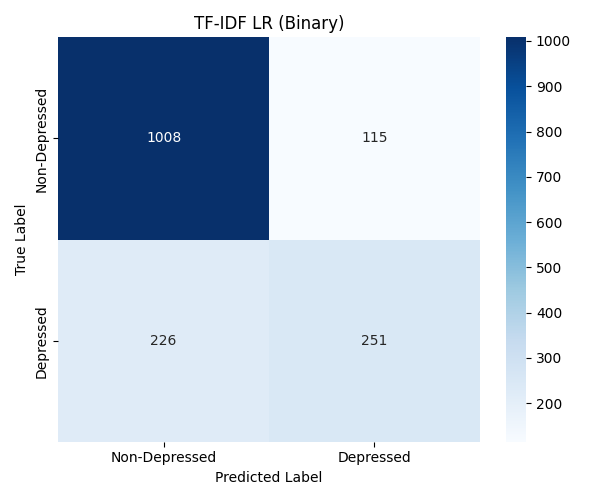


Showing conf_bert_binary.png


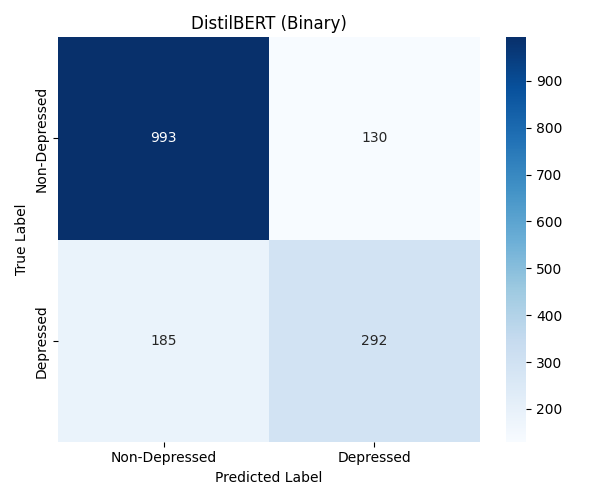


Showing conf_seen_binary.png


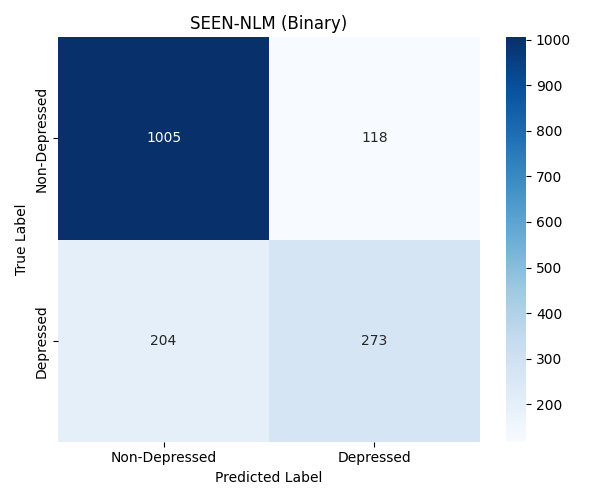


Showing roc_binary_models.png


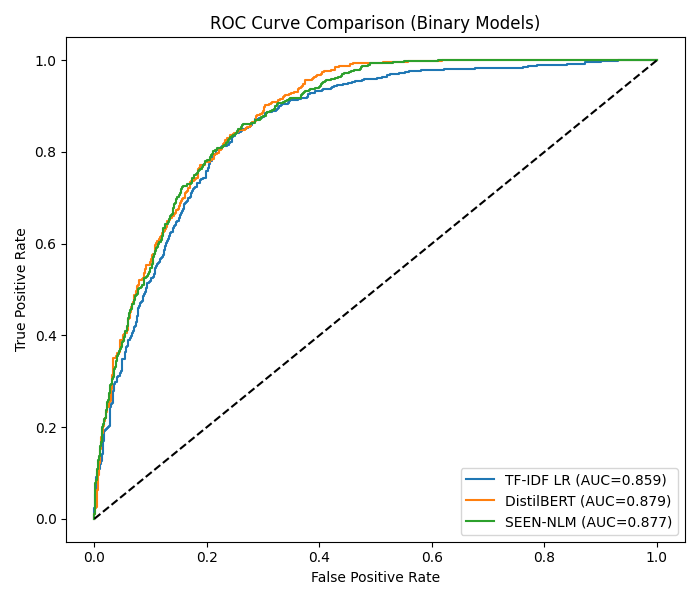


Showing f1_comparison_binary.png


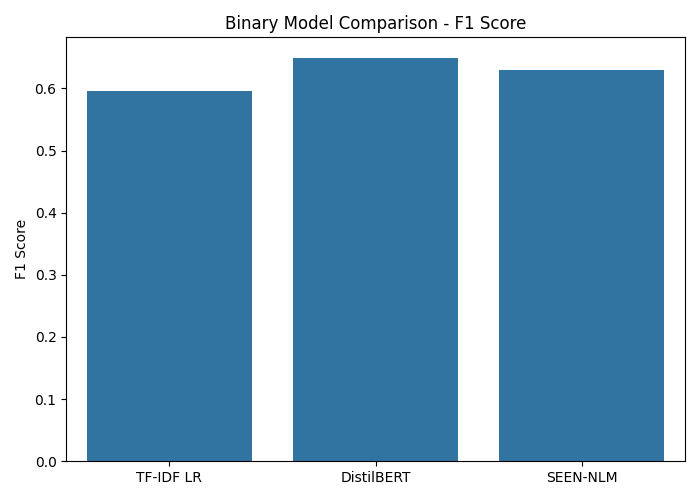


Showing accuracy_comparison_binary.png


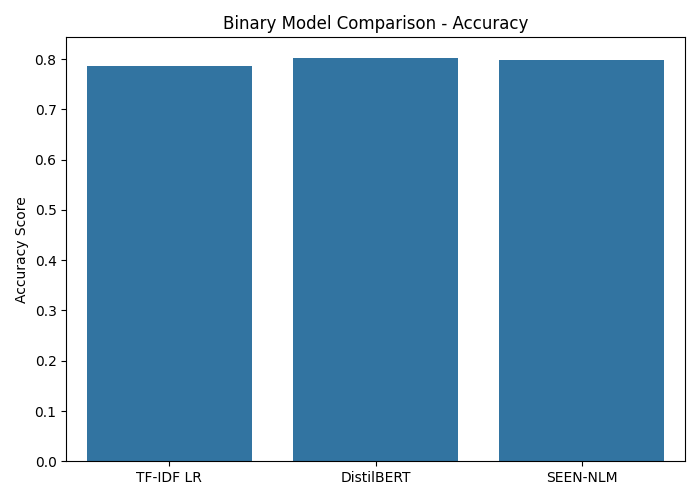


Showing wordcloud_dep_normal.png


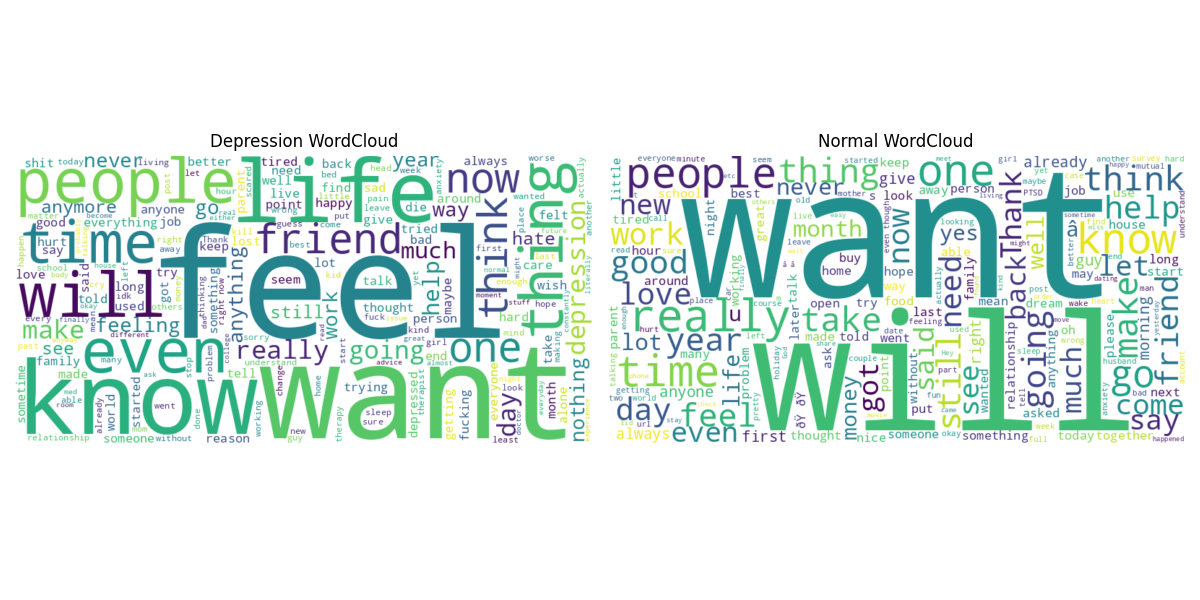


Showing sentiment_comparison.png


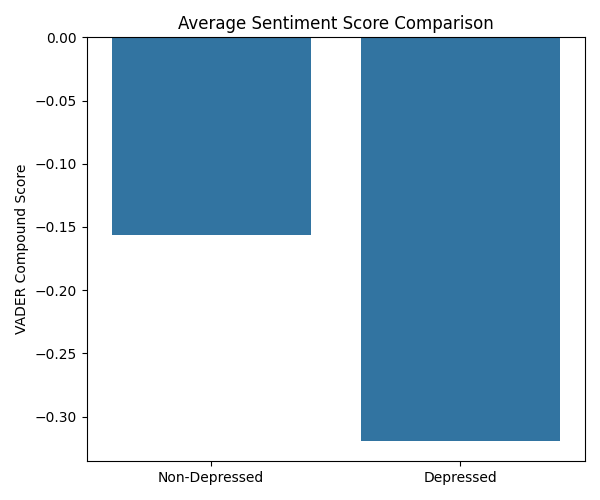

In [ ]:

# PART 2 → ADVANCED ANALYSIS & VISUALIZATIONS


print("\n\n GENERATING GRAPHS & ANALYSIS \n")


def plot_conf_matrix(y_true, y_pred, title, filename, labels=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()


binary_labels = ["Non-Depressed", "Depressed"]

plot_conf_matrix(y_test_bin, pred_lr, "TF-IDF LR (Binary)", "conf_tfidf_binary.png", binary_labels)
plot_conf_matrix(y_test_bin, preds_b, "DistilBERT (Binary)", "conf_bert_binary.png", binary_labels)
plot_conf_matrix(y_test_bin, preds_s, "SEEN-NLM (Binary)", "conf_seen_binary.png", binary_labels)



# ROC CURVE (Binary)

print(" ROC Curve (Binary Models)...")

plt.figure(figsize=(7, 6))

# TF-IDF
fpr_lr, tpr_lr, _ = roc_curve(y_test_bin, prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f"TF-IDF LR (AUC={auc_lr:.3f})")

# DistilBERT
fpr_b, tpr_b, _ = roc_curve(y_test_bin, probs_b)
auc_b = auc(fpr_b, tpr_b)
plt.plot(fpr_b, tpr_b, label=f"DistilBERT (AUC={auc_b:.3f})")

# SEEN-NLM
fpr_s, tpr_s, _ = roc_curve(y_test_bin, probs_s)
auc_s = auc(fpr_s, tpr_s)
plt.plot(fpr_s, tpr_s, label=f"SEEN-NLM (AUC={auc_s:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve Comparison (Binary Models)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("roc_binary_models.png")
plt.close()

print(" ROC Curve Saved")



# F1 SCORE BAR CHART

print(" F1 Score Bar Chart...")

models = ["TF-IDF LR", "DistilBERT", "SEEN-NLM"]
f1_scores = [f1_lr, f1_b, f1_s]

plt.figure(figsize=(7, 5))
sns.barplot(x=models, y=f1_scores)
plt.title("Binary Model Comparison - F1 Score")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.savefig("f1_comparison_binary.png")
plt.close()

print(" F1 Score Chart Saved")



# ACCURACY BAR CHART

print("Accuracy Bar Chart...")

acc_lr = accuracy_score(y_test_bin, pred_lr)
acc_b = accuracy_score(y_test_bin, preds_b)
acc_s = accuracy_score(y_test_bin, preds_s)

accs = [acc_lr, acc_b, acc_s]

plt.figure(figsize=(7, 5))
sns.barplot(x=models, y=accs)
plt.title("Binary Model Comparison - Accuracy")
plt.ylabel("Accuracy Score")
plt.tight_layout()
plt.savefig("accuracy_comparison_binary.png")
plt.close()

print(" Accuracy Chart Saved")



# WORDCLOUDS (Depression vs Normal)

print(" Creating Depression vs Normal Wordcloud...")

try:
    dep_text = " ".join(df[df["status"] == "Depression"]["statement"].tolist())
    norm_text = " ".join(df[df["status"] == "Normal"]["statement"].tolist())

    wc_dep = WordCloud(width=800, height=400, background_color="white").generate(dep_text)
    wc_norm = WordCloud(width=800, height=400, background_color="white").generate(norm_text)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(wc_dep, interpolation="bilinear")
    plt.axis("off")
    plt.title("Depression WordCloud")

    plt.subplot(1, 2, 2)
    plt.imshow(wc_norm, interpolation="bilinear")
    plt.axis("off")
    plt.title("Normal WordCloud")

    plt.tight_layout()
    plt.savefig("wordcloud_dep_normal.png")
    plt.close()

    print("✔ Wordcloud Saved")

except:
    print("⚠ Not enough samples for wordcloud")



# SENTIMENT DISTRIBUTION GRAPH

print(" Creating Sentiment Comparison Bar Graph...")

df["sentiment_comp"] = df["statement"].apply(lambda x: sia.polarity_scores(x)["compound"])

avg_dep = df[df["binary_label"] == 1]["sentiment_comp"].mean()
avg_non = df[df["binary_label"] == 0]["sentiment_comp"].mean()

plt.figure(figsize=(6, 5))
sns.barplot(x=["Non-Depressed", "Depressed"], y=[avg_non, avg_dep])
plt.title("Average Sentiment Score Comparison")
plt.ylabel("VADER Compound Score")
plt.tight_layout()
plt.savefig("sentiment_comparison.png")
plt.close()

print("✔ Sentiment Graph Saved")



# MISCLASSIFIED EXAMPLES

print("\n Showing Correctly Predicted Examples (SEEN-NLM)\n")

correct_idx = np.where(np.array(y_test_bin) == np.array(preds_s))[0]

label_map = {0: "Non-Depressed", 1: "Depressed"}

for i in correct_idx[:10]:  # show first 10 correct predictions
    print("\n----------------------------------")
    print("Text:", X_test_bin.iloc[i])
    print("Actual:", label_map[y_test_bin.iloc[i]])
    print("Predicted:", label_map[preds_s[i]])


print("\n Showing Misclassified Examples (SEEN-NLM)")

wrong_idx = np.where(np.array(y_test_bin) != np.array(preds_s))[0]

label_map = {0: "Non-Depressed", 1: "Depressed"}

for i in wrong_idx[:10]:
    print("Text:", X_test_bin.iloc[i])
    print("Actual:", label_map[y_test_bin.iloc[i]])
    print("Predicted:", label_map[preds_s[i]])


print("\n Classification Report — SEEN-NLM")
print(classification_report(y_test_bin, preds_s, target_names=["Non-Depressed", "Depressed"]))

print("\n ALL ANALYSIS COMPLETED. All graphs saved successfully!")
from IPython.display import Image, display

files = [
    "conf_tfidf_binary.png",
    "conf_bert_binary.png",
    "conf_seen_binary.png",
    "roc_binary_models.png",
    "f1_comparison_binary.png",
    "accuracy_comparison_binary.png",
    "wordcloud_dep_normal.png",
    "sentiment_comparison.png"
]

for f in files:
    print(f"\nShowing {f}")
    display(Image(f))

